# CS-4063 NLP Assignment 2 - i23-2538

GitHub URL: https://github.com/YOUR_USERNAME/i23-2538-NLP-Assignment

This notebook compiles all required outputs for submission.


In [53]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path(".")
REPORTS = ROOT / "reports"
EMB = ROOT / "embeddings"

with (REPORTS / "part1_tfidf_top_words.json").open("r", encoding="utf-8") as f:
    tfidf_top = json.load(f)
with (REPORTS / "part1_w2v_eval.json").open("r", encoding="utf-8") as f:
    w2v_eval = json.load(f)
with (REPORTS / "part1_condition_comparison.json").open("r", encoding="utf-8") as f:
    condition_cmp = json.load(f)
with (REPORTS / "part2_results.json").open("r", encoding="utf-8") as f:
    part2 = json.load(f)
with (REPORTS / "part3_results.json").open("r", encoding="utf-8") as f:
    part3 = json.load(f)
comparison_text = (REPORTS / "part3_bilstm_vs_transformer.txt").read_text(encoding="utf-8")

print("Loaded report artifacts successfully.")


Loaded report artifacts successfully.


## Part 1 - Word Embeddings


In [24]:
print("Top-10 TF-IDF discriminative words per topic")
print("=" * 72)
for topic, pairs in tfidf_top.items():
    print()
    print(f"[{topic}]")
    for rank, (word, score) in enumerate(pairs[:10], start=1):
        print(f"{rank:2d}. {word:15s} {score:.4f}")

Top-10 TF-IDF discriminative words per topic

[Sports]
 1. score           2.1037
 2. stadium         2.0713
 3. player          2.0589
 4. tournament      2.0371
 5. match           2.0030
 6. team            1.9858
 7. coach           1.9213
 8. cricket         1.8357
 9. karachi         0.4974
10. ;               0.4953

[Politics]
 1. fauj            2.0256
 2. hukumat         2.0219
 3. government      1.9082
 4. minister        1.8618
 5. parliament      1.8122
 6. policy          1.7881
 7. adalat          1.7609
 8. election        1.6127
 9. barh            0.4852
10. !               0.4456

[Economy]
 1. bank            2.0606
 2. maeeshat        1.8857
 3. trade           1.8332
 4. market          1.8297
 5. tax             1.7819
 6. budget          1.7505
 7. gdp             1.7495
 8. inflation       1.6075
 9. nizam           0.5680
10. karachi         0.4873

[International]
 1. border          2.1277
 2. conflict        2.0256
 3. diplomacy       1.9986
 4. foreign   

PPMI t-SNE plot (Top-200 frequent words)


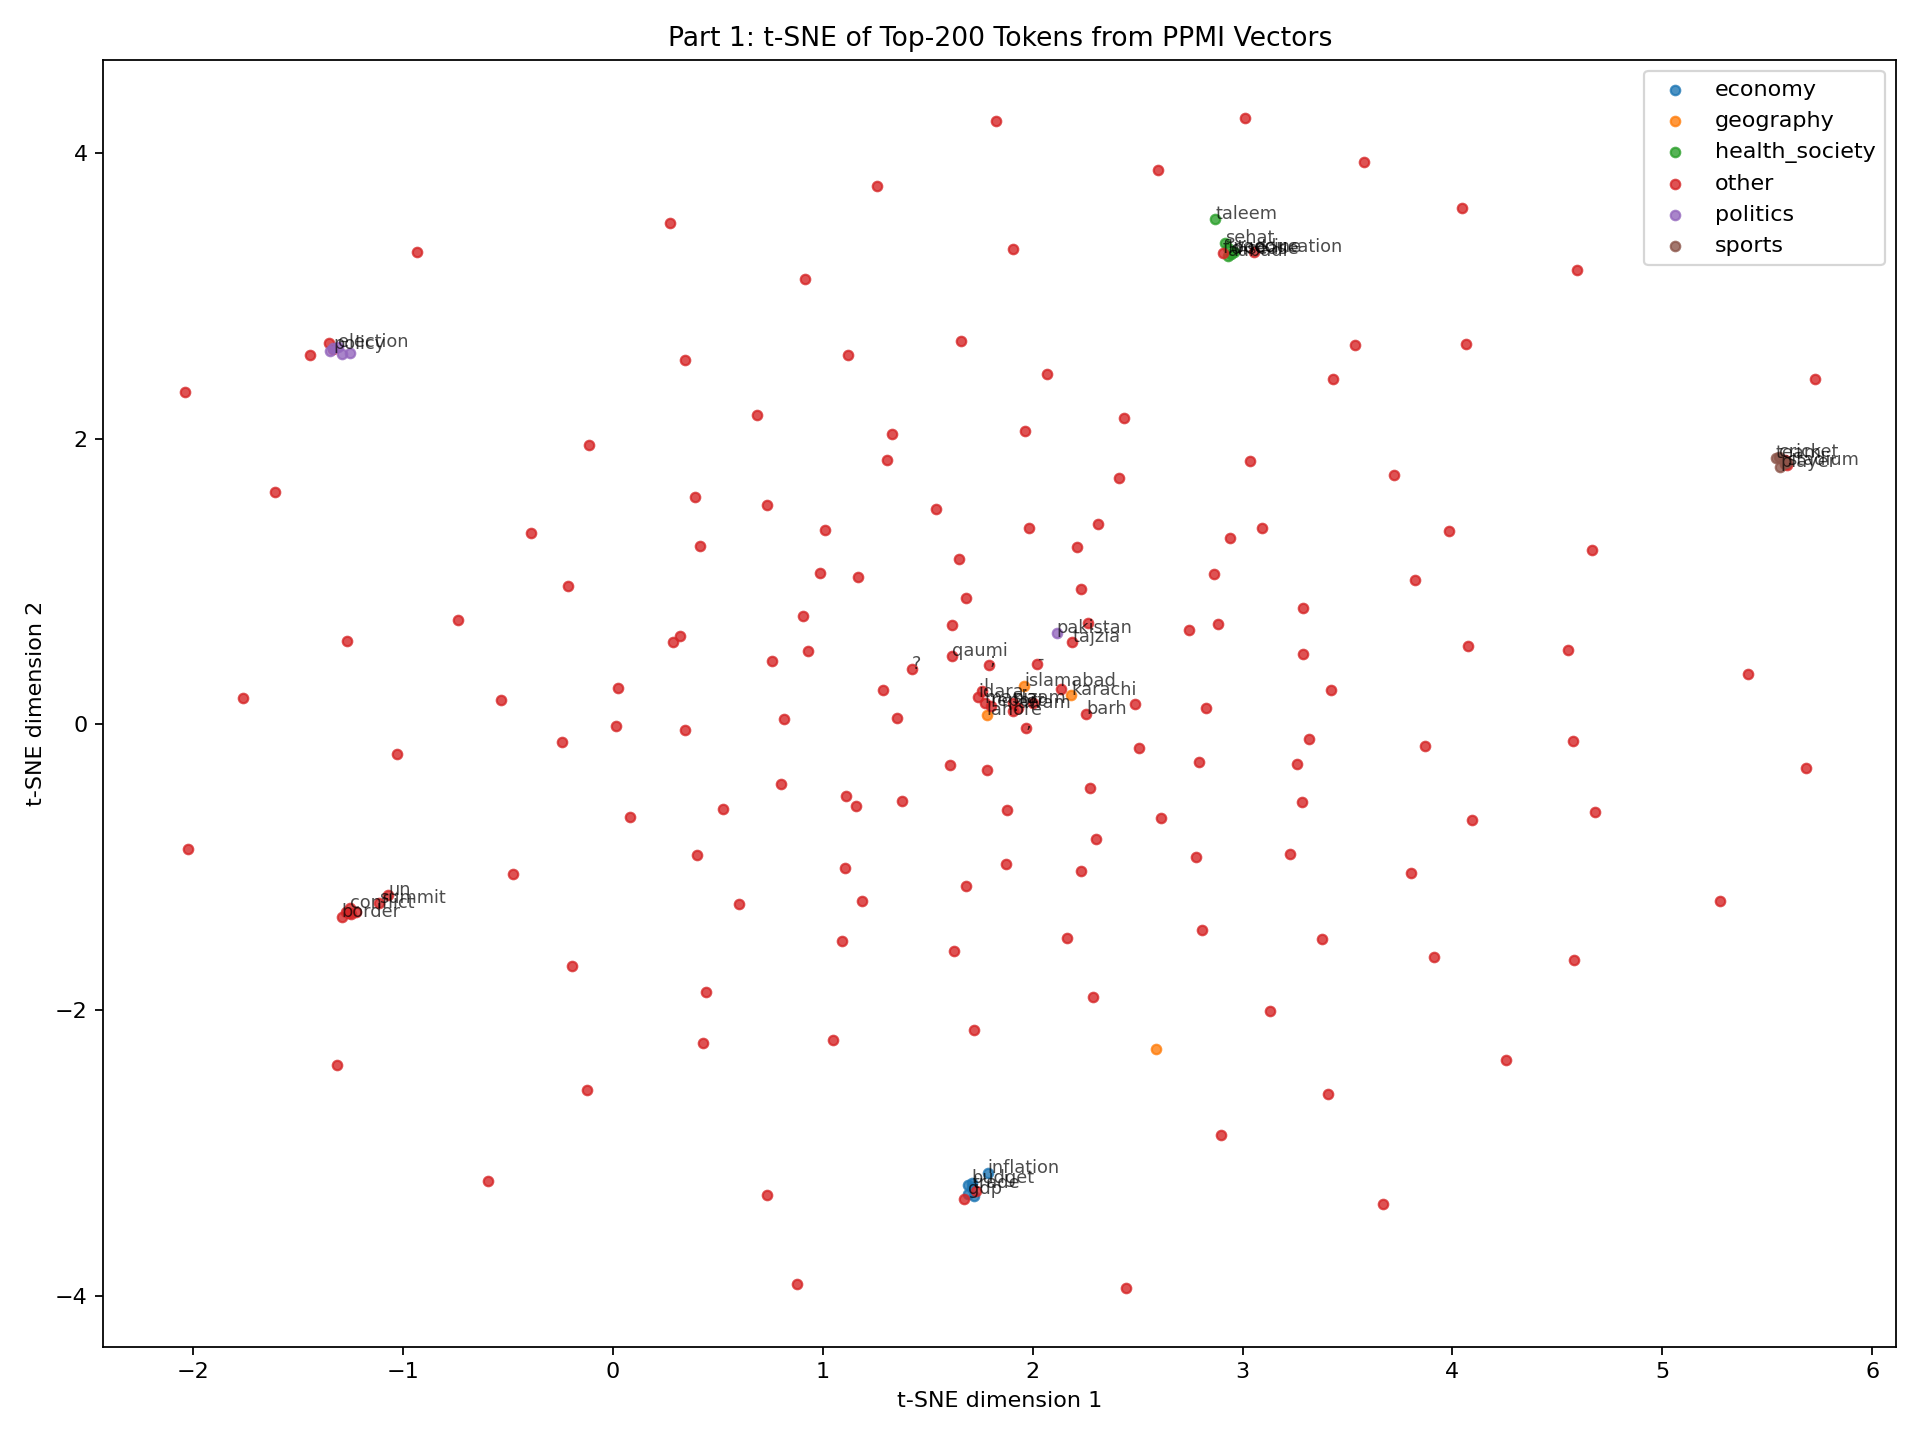

In [25]:
print("PPMI t-SNE plot (Top-200 frequent words)")
display(Image(filename=str(REPORTS / "part1_ppmi_tsne.png")))


In [26]:
print("Top-5 nearest neighbours for 10 query words using PPMI matrix")
ppmi = np.load(EMB / "ppmi_matrix.npy")
with (EMB / "word2idx.json").open("r", encoding="utf-8") as f:
    word2idx = json.load(f)
idx2word = [None] * len(word2idx)
for w, i in word2idx.items():
    if i < len(idx2word):
        idx2word[i] = w

row_norm = np.linalg.norm(ppmi, axis=1, keepdims=True) + 1e-12
ppmi_norm = ppmi / row_norm

queries = ["pakistan", "hukumat", "adalat", "maeeshat", "fauj", "sehat", "taleem", "aabadi", "education", "hospital"]
for q in queries:
    if q not in word2idx:
        print()
        print(f"{q}: missing from vocabulary")
        continue
    qi = word2idx[q]
    sims = ppmi_norm @ ppmi_norm[qi]
    order = np.argsort(-sims)
    print()
    print(f"{q}:")
    count = 0
    for j in order:
        if j == qi:
            continue
        tok = idx2word[j] if j < len(idx2word) else "<NA>"
        if tok in ["<PAD>", "<UNK>", "<CLS>"]:
            continue
        print(f"  - {tok:15s} {float(sims[j]):.4f}")
        count += 1
        if count >= 5:
            break

Top-5 nearest neighbours for 10 query words using PPMI matrix

pakistan:
  - par             0.4288
  - 4               0.3902
  - 11              0.3775
  - teen            0.3720
  - coach           0.3647

hukumat:
  - adalat          0.6350
  - parliament      0.6308
  - government      0.6095
  - minister        0.5984
  - policy          0.5682

adalat:
  - parliament      0.6441
  - hukumat         0.6350
  - government      0.6308
  - fauj            0.6220
  - election        0.6092

maeeshat:
  - budget          0.6603
  - bank            0.6594
  - tax             0.6501
  - trade           0.6332
  - gdp             0.5982

fauj:
  - policy          0.6595
  - parliament      0.6333
  - adalat          0.6220
  - government      0.6157
  - election        0.5923

sehat:
  - hospital        0.6455
  - aabadi          0.6203
  - vaccine         0.6135
  - education       0.6017
  - flood           0.5954

taleem:
  - aabadi          0.6172
  - hospital        0.5940
  - flood

Skip-gram training loss curve


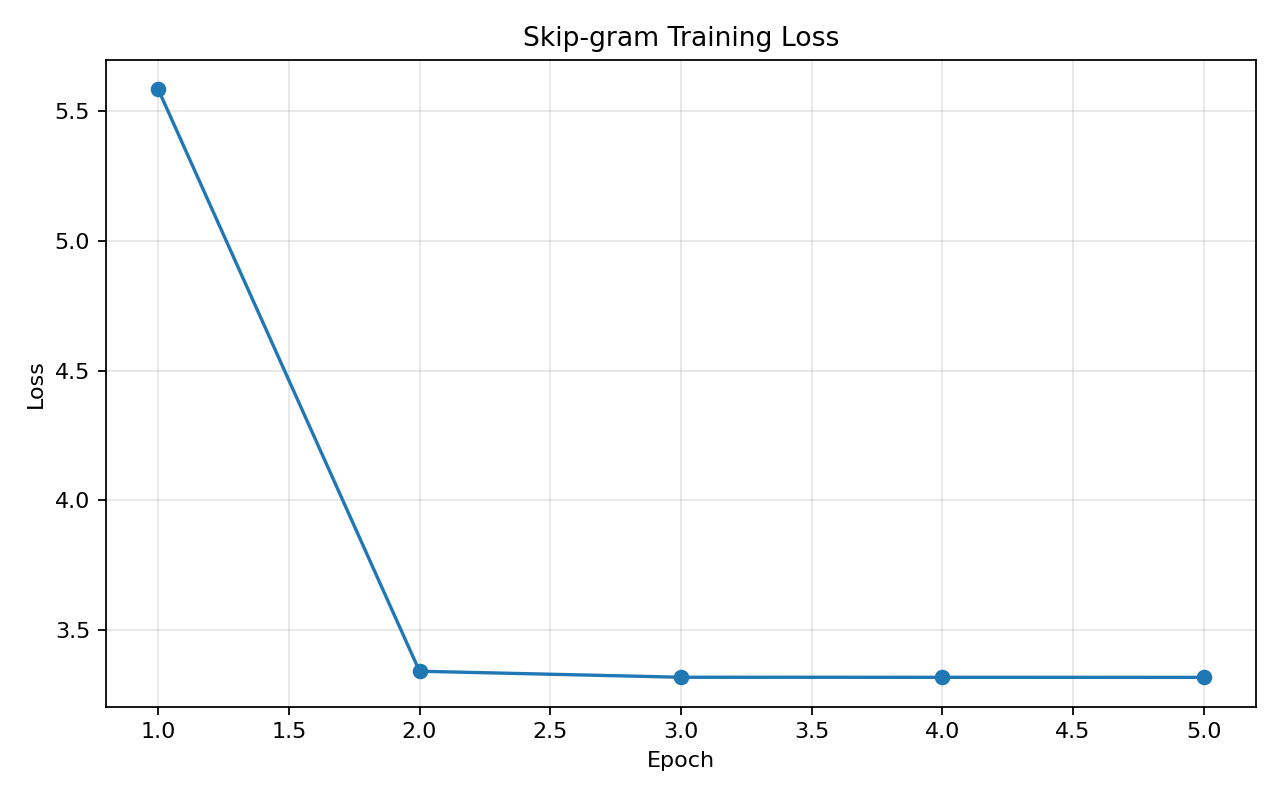

In [27]:
print("Skip-gram training loss curve")
display(Image(filename=str(REPORTS / "part1_skipgram_loss.png")))


In [28]:
print("Top-10 nearest neighbours for 8 Word2Vec query words")
print("=" * 72)
for query, neighbors in w2v_eval["nearest_neighbors"].items():
    print()
    print(f"{query}:")
    for rank, item in enumerate(neighbors[:10], start=1):
        word, sim = item
        print(f"{rank:2d}. {word:15s} {sim:.4f}")

Top-10 nearest neighbours for 8 Word2Vec query words

pakistan:
 1. tajzia          0.8926
 2. idara           0.8748
 3. awam            0.8722
 4. report          0.8637
 5. nizam           0.8544
 6. qaumi           0.8534
 7. islamabad       0.8515
 8. lahore          0.8509
 9. karachi         0.8347
10. barh            0.8201

hukumat:
 1. policy          0.9420
 2. election        0.9323
 3. parliament      0.9288
 4. fauj            0.9232
 5. minister        0.8275
 6. government      0.7855
 7. adalat          0.7445
 8. qaumi           0.6768
 9. barh            0.6215
10. lahore          0.6198

adalat:
 1. government      0.8907
 2. minister        0.8718
 3. fauj            0.8357
 4. parliament      0.8286
 5. policy          0.8057
 6. hukumat         0.7445
 7. election        0.7272
 8. mein            0.3191
 9. har             0.2830
10. qaumi           0.2009

maeeshat:
 1. budget          0.9512
 2. gdp             0.9351
 3. inflation       0.9274
 4. tax        

In [29]:
print("Analogy results: top-3 candidates")
print("=" * 72)
for analogy, preds in w2v_eval["analogies"].items():
    print()
    print(f"{analogy}")
    if not preds:
        print("  No candidates available (missing query terms in vocabulary).")
        continue
    for rank, item in enumerate(preds[:3], start=1):
        word, sim = item
        print(f"  {rank}. {word:15s} {sim:.4f}")

Analogy results: top-3 candidates

pakistan:hukumat::adalat:?
  1. government      0.9235
  2. minister        0.9076
  3. fauj            0.8734

sehat:hospital::taleem:?
  1. disease         0.7852
  2. education       0.7576
  3. vaccine         0.7454

team:match::player:?
  1. score           0.9228
  2. stadium         0.9192
  3. tournament      0.9045

bank:maeeshat::budget:?
  1. gdp             0.8247
  2. inflation       0.8039
  3. trade           0.7917

lahore:punjab::karachi:?
  1. nawaz           0.9817
  2. larkana         0.9815
  3. mirpur          0.9812

wazir:hukumat::player:?
  No candidates available (missing query terms in vocabulary).

vaccine:hospital::disease:?
  1. aabadi          0.8780
  2. sehat           0.8752
  3. education       0.8727

fauj:hukumat::adalat:?
  1. parliament      0.8803
  2. policy          0.8607
  3. minister        0.8397

cricket:sports::economy:?
  No candidates available (missing query terms in vocabulary).

inflation:economy::

In [30]:
print("Four-condition comparison with MRR")
print("=" * 72)
for cid in ["C1", "C2", "C3", "C4"]:
    desc = condition_cmp[cid]["description"]
    mrr = condition_cmp.get("mrr", {}).get(cid, 0.0)
    print(f"{cid}: {desc:32s} MRR={mrr:.4f}")


Four-condition comparison with MRR
C1: PPMI baseline                    MRR=1.0000
C2: Skip-gram on raw                 MRR=0.1333
C3: Skip-gram on cleaned             MRR=0.1000
C4: Skip-gram on cleaned, d=200      MRR=0.0125


## Part 2 - BiLSTM Sequence Labeling


In [31]:
print("POS and NER class-label distributions")
print("=" * 72)
print("POS distribution:")
for k, v in part2["label_distribution"]["pos"].items():
    print(f"  {k:8s}: {v}")

print()
print("NER distribution:")
for k, v in part2["label_distribution"]["ner"].items():
    print(f"  {k:8s}: {v}")

POS and NER class-label distributions
POS distribution:
  NOUN    : 6546
  PUNC    : 971
  ADJ     : 1346
  ADV     : 205
  POST    : 357
  NUM     : 508
  PRON    : 375
  DET     : 201
  CONJ    : 226
  VERB    : 103
  UNK     : 17

NER distribution:
  B-ORG   : 820
  B-LOC   : 986
  O       : 6510
  B-MISC  : 1686
  B-PER   : 853


BiLSTM training and validation curves

part2_pos_frozen_curve.png


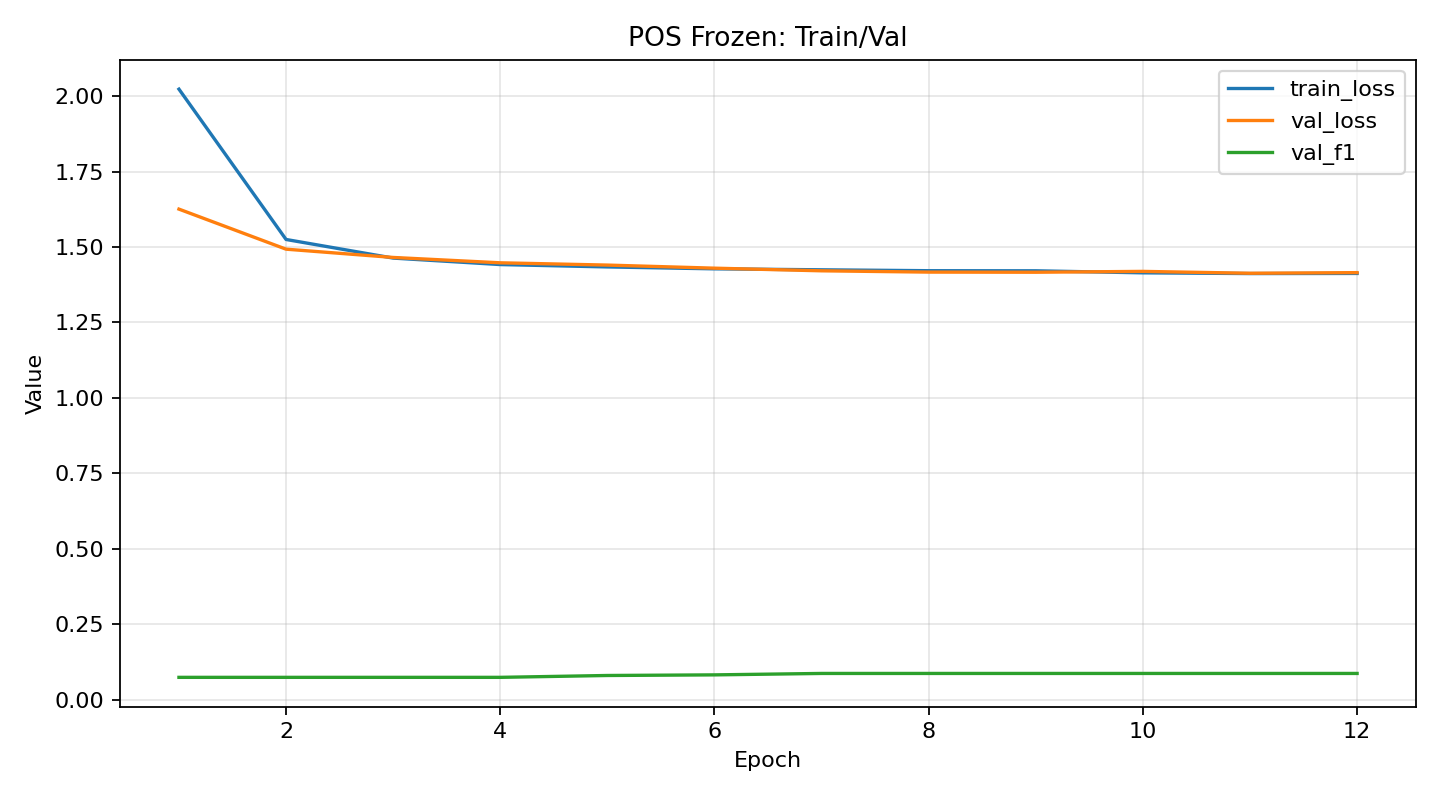


part2_pos_finetuned_curve.png


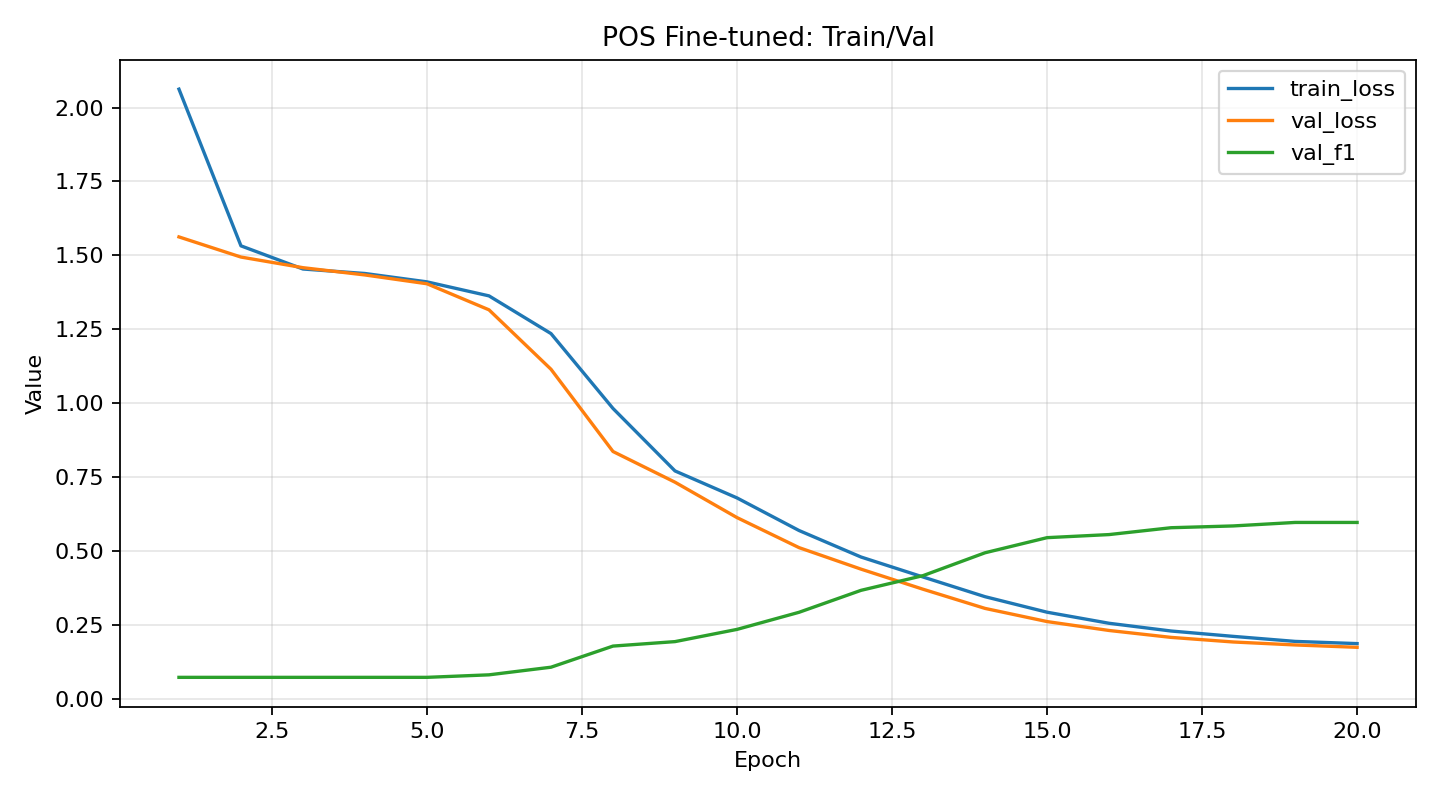


part2_ner_crf_curve.png


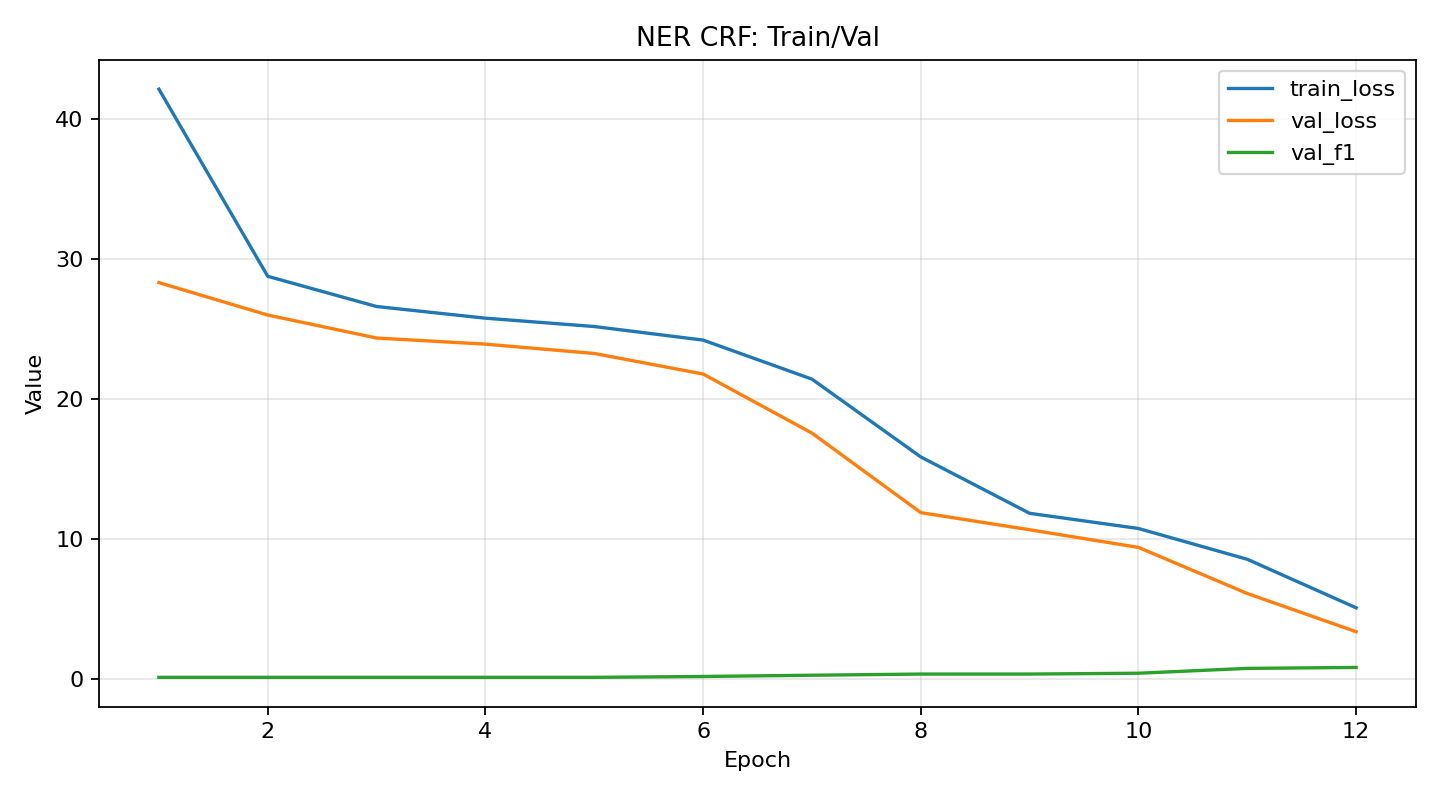


part2_ner_softmax_curve.png


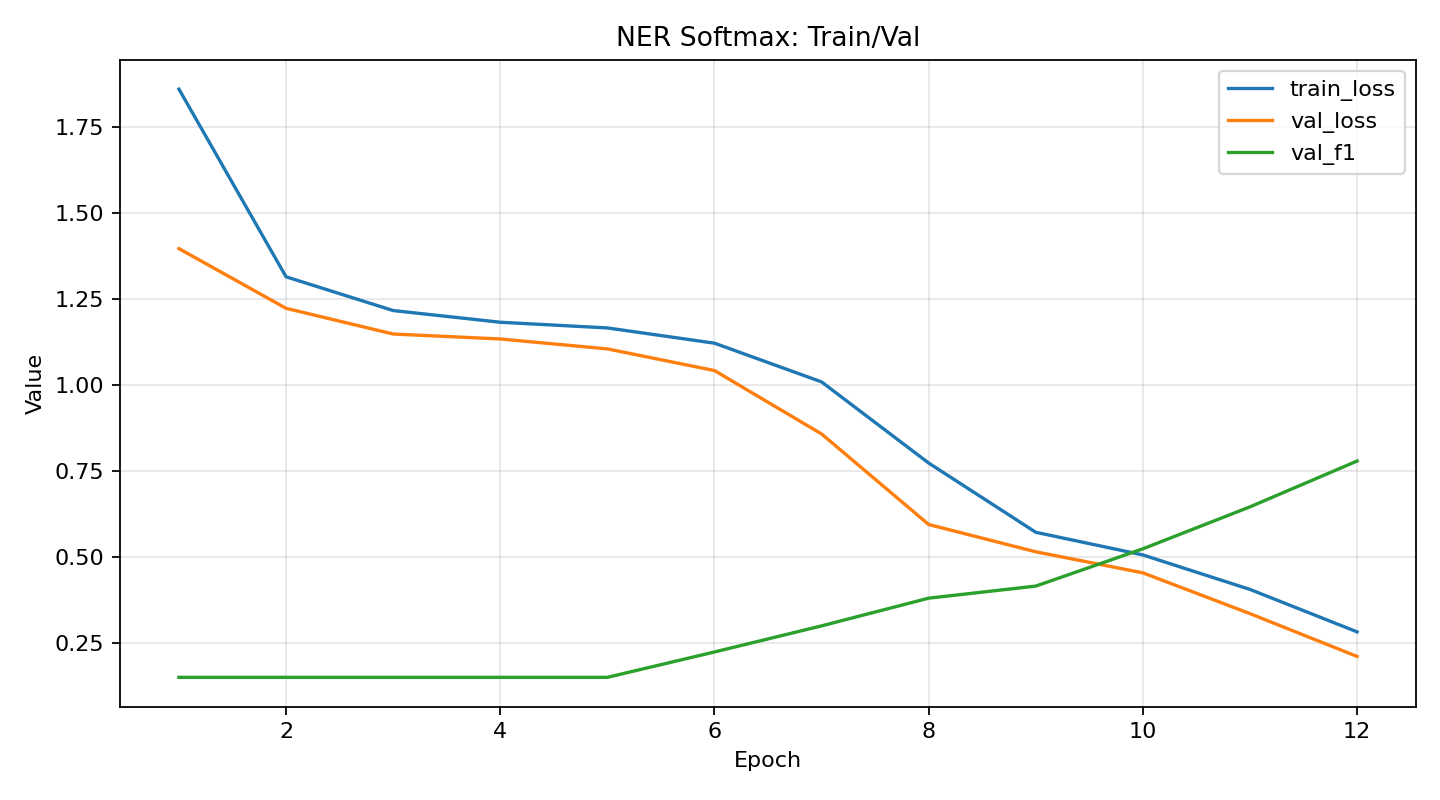

In [48]:
print("BiLSTM training and validation curves")
for name in [
    "part2_pos_frozen_curve.png",
    "part2_pos_finetuned_curve.png",
    "part2_ner_crf_curve.png",
    "part2_ner_softmax_curve.png",
]:
    print()
    print(f"{name}")
    display(Image(filename=str(REPORTS / name)))

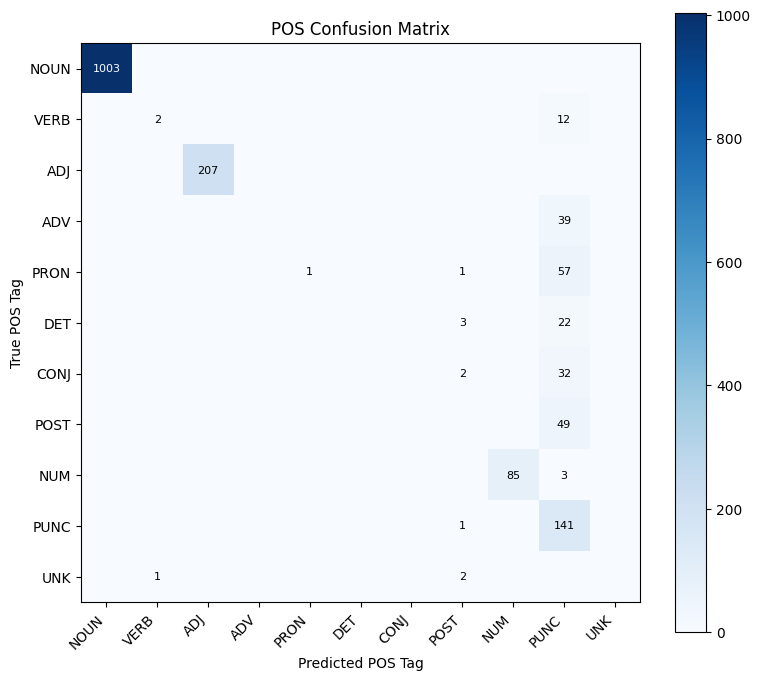

In [54]:
pos_tags = ["NOUN", "VERB", "ADJ", "ADV", "PRON", "DET", "CONJ", "POST", "NUM", "PUNC", "UNK"]
pos_cm = np.array(part2["pos"]["confusion_matrix"])
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(pos_cm, cmap="Blues")
ax.set_title("POS Confusion Matrix")
ax.set_xlabel("Predicted POS Tag")
ax.set_ylabel("True POS Tag")
ax.set_xticks(np.arange(len(pos_tags)))
ax.set_yticks(np.arange(len(pos_tags)))
ax.set_xticklabels(pos_tags, rotation=45, ha="right")
ax.set_yticklabels(pos_tags)

thresh = pos_cm.max() / 2 if pos_cm.size else 0
for i in range(pos_cm.shape[0]):
    for j in range(pos_cm.shape[1]):
        if pos_cm[i, j] > 0:
            ax.text(
                j,
                i,
                str(int(pos_cm[i, j])),
                ha="center",
                va="center",
                fontsize=8,
                color="white" if pos_cm[i, j] > thresh else "black",
            )

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


In [34]:
print("NER conlleval-style entity scores (per type + overall)")
print("=" * 72)
for entity, vals in part2["ner"]["with_crf"].items():
    print(f"{entity:8s} P={vals['precision']:.4f} R={vals['recall']:.4f} F1={vals['f1']:.4f}")

print()
print("CRF vs No-CRF (overall F1)")
f1_crf = part2["ner"]["with_crf"]["overall"]["f1"]
f1_nocrf = part2["ner"]["without_crf"]["overall"]["f1"]
print(f"With CRF    : {f1_crf:.4f}")
print(f"Without CRF : {f1_nocrf:.4f}")

NER conlleval-style entity scores (per type + overall)
PER      P=0.7303 R=0.4924 F1=0.5882
LOC      P=0.9925 R=0.9779 F1=0.9852
ORG      P=0.6149 R=0.8168 F1=0.7016
MISC     P=0.9880 R=0.9960 F1=0.9920
overall  P=0.8532 R=0.8532 F1=0.8532

CRF vs No-CRF (overall F1)
With CRF    : 0.8532
Without CRF : 0.8022


In [35]:
print("Ablation study (A1-A4)")
print("=" * 72)
for aid, vals in part2["ablations"].items():
    desc = vals.get("description", "")
    pos_f1 = vals.get("pos_macro_f1", None)
    ner_f1 = vals.get("ner_overall_f1", None)
    print(f"{aid}: {desc}")
    if pos_f1 is not None:
        print(f"  POS macro-F1: {pos_f1:.4f}")
    if ner_f1 is not None:
        print(f"  NER overall-F1: {ner_f1:.4f}")


Ablation study (A1-A4)
A1: Unidirectional LSTM
  POS macro-F1: 0.0684
  NER overall-F1: 0.0000
A2: No dropout
  POS macro-F1: 0.1746
  NER overall-F1: 0.4436
A3: Random embeddings
  POS macro-F1: 0.1833
  NER overall-F1: 0.4112
A4: Softmax instead of CRF
  NER overall-F1: 0.3438


## Part 3 - Transformer Encoder Topic Classification


Transformer training/validation curves


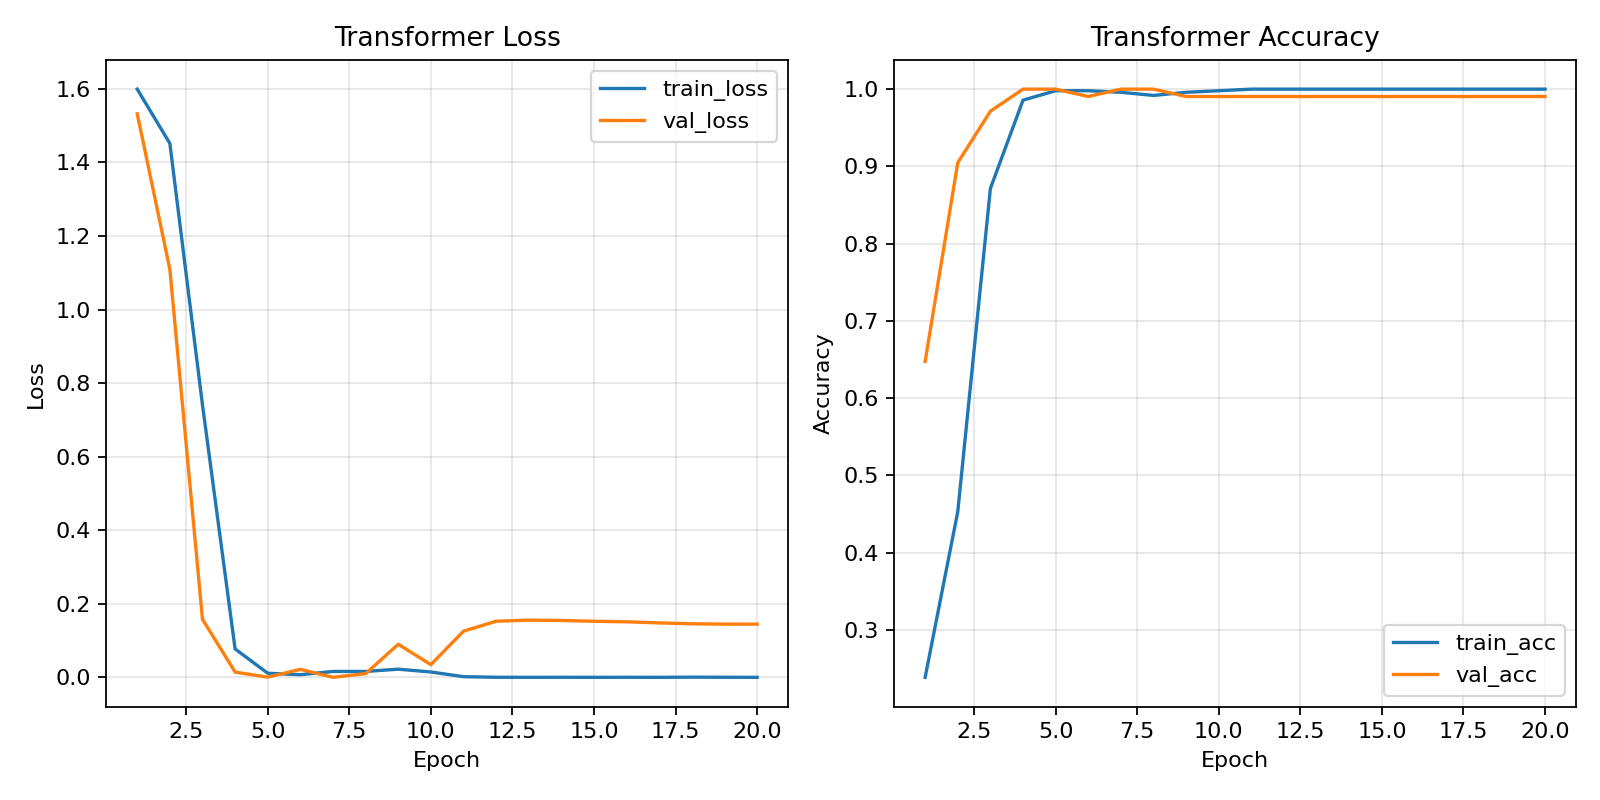


BiLSTM baseline training/validation curves


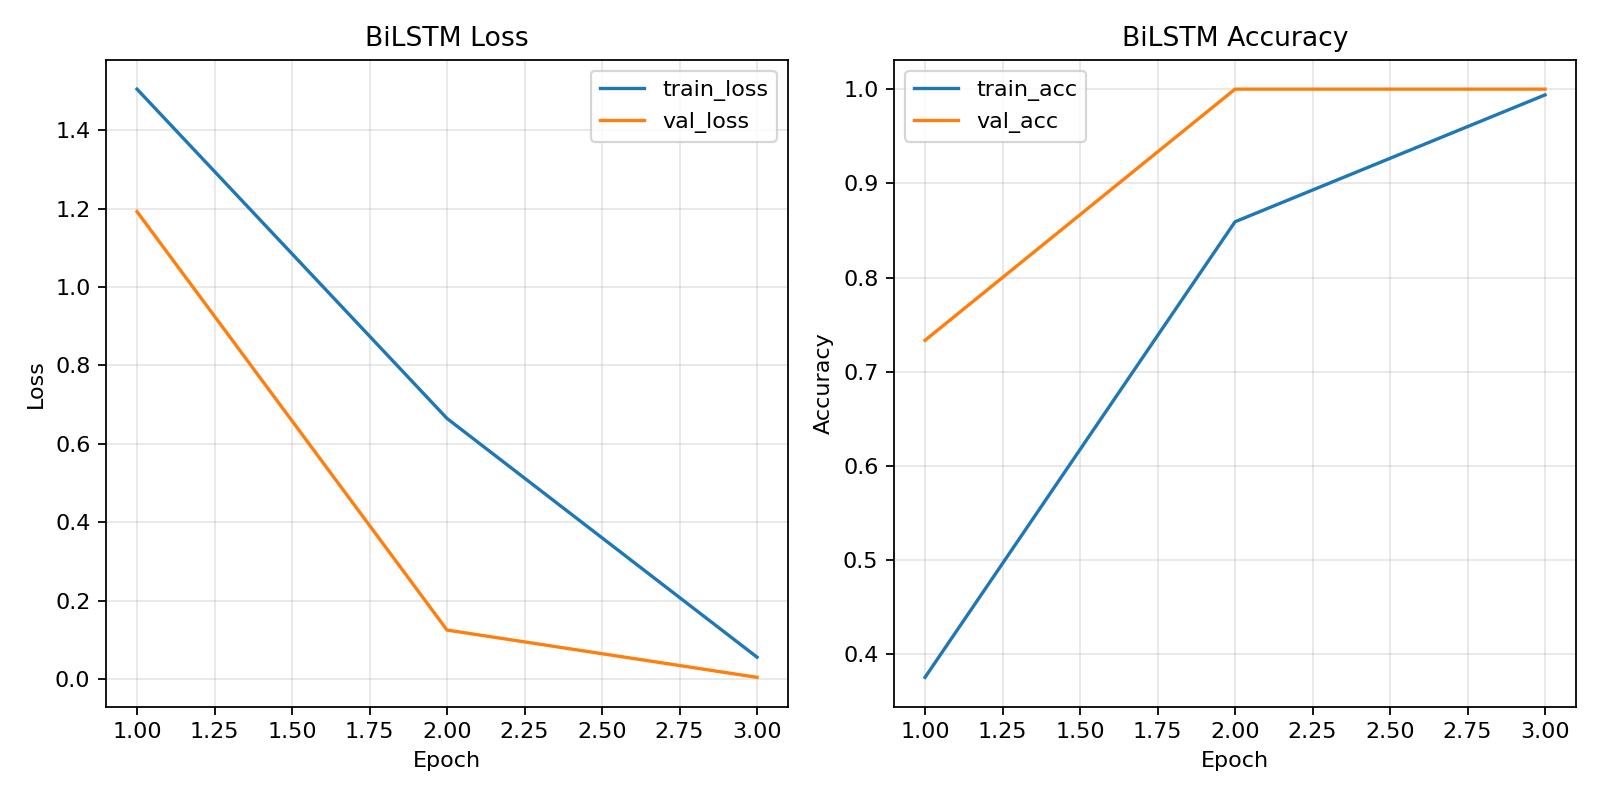

In [50]:
print("Transformer training/validation curves")
display(Image(filename=str(REPORTS / "part3_transformer_curves.png")))

print()
print("BiLSTM baseline training/validation curves")
display(Image(filename=str(REPORTS / "part3_bilstm_curves.png")))

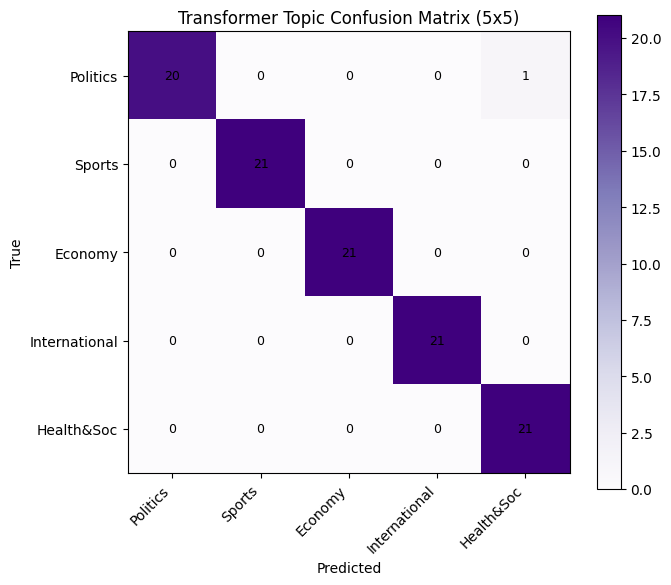

In [51]:
cm = np.array(part3["transformer"]["confusion_matrix"])
labels = ["Politics", "Sports", "Economy", "International", "Health&Soc"]
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Purples")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_title("Transformer Topic Confusion Matrix (5x5)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black", fontsize=9)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


Attention heatmaps (2 heads x 3 correctly classified articles)

part3_attention_article1_head0.png


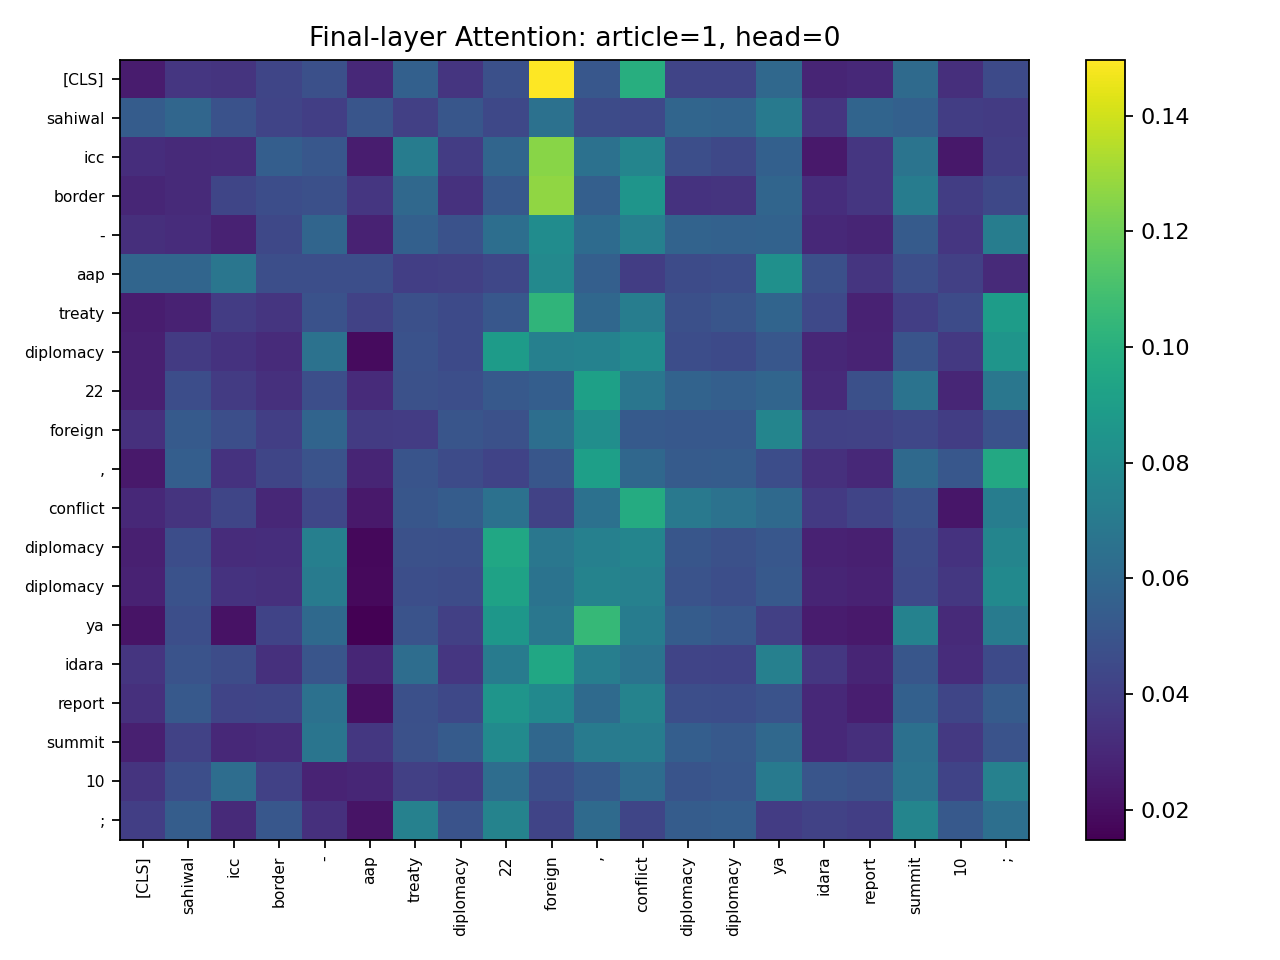


part3_attention_article1_head1.png


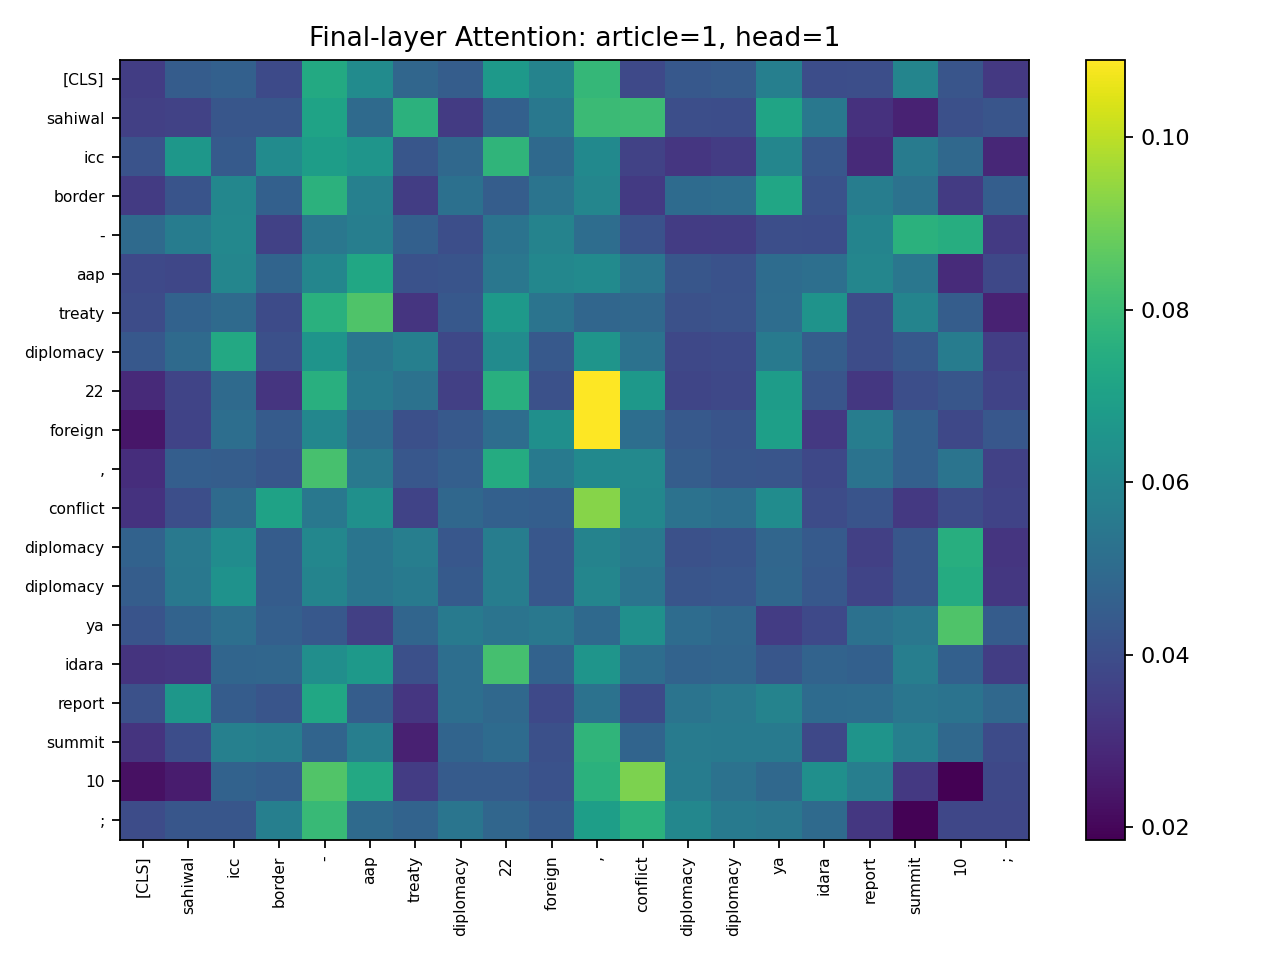


part3_attention_article2_head0.png


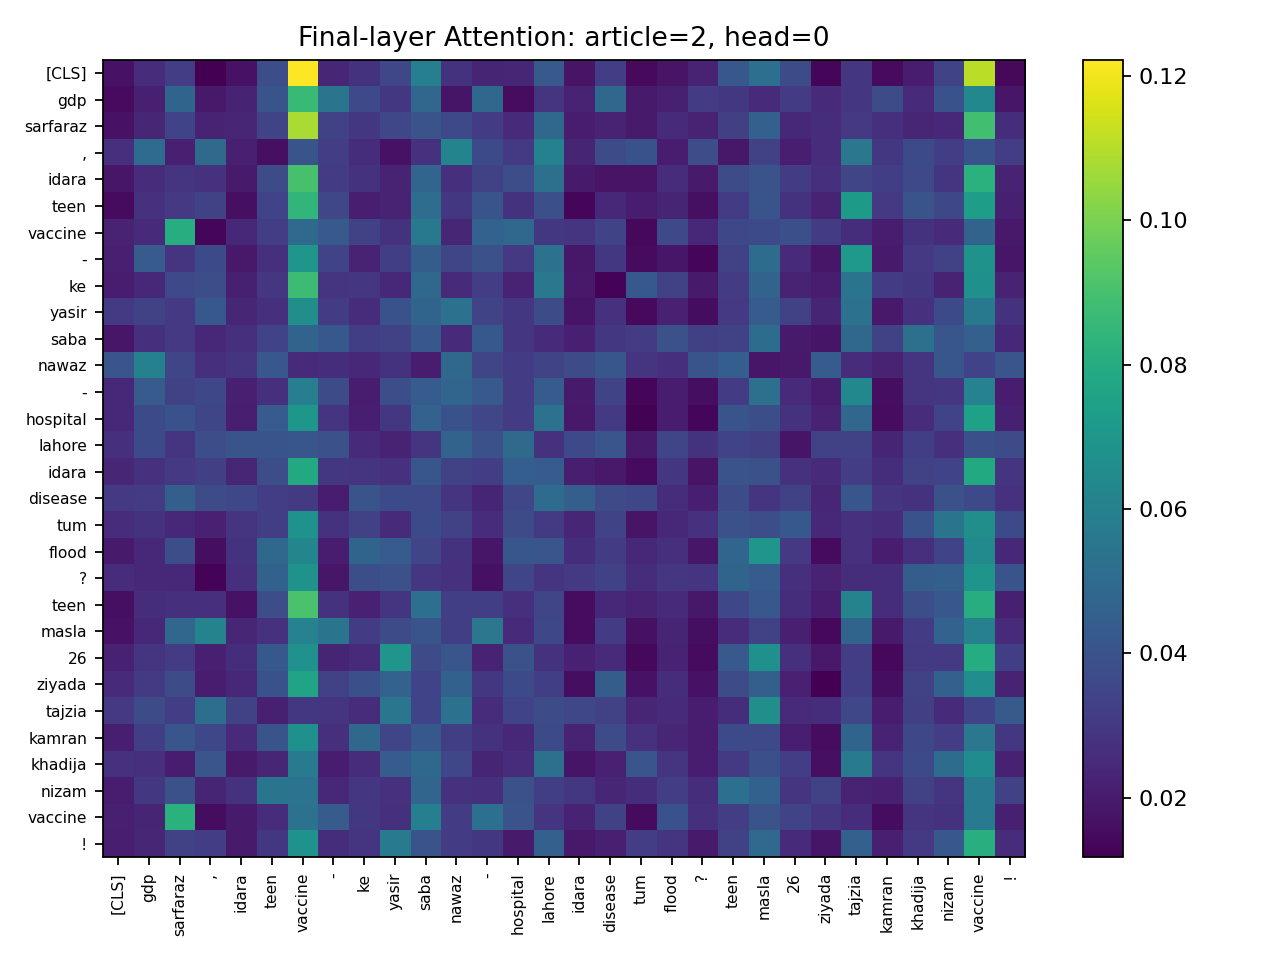


part3_attention_article2_head1.png


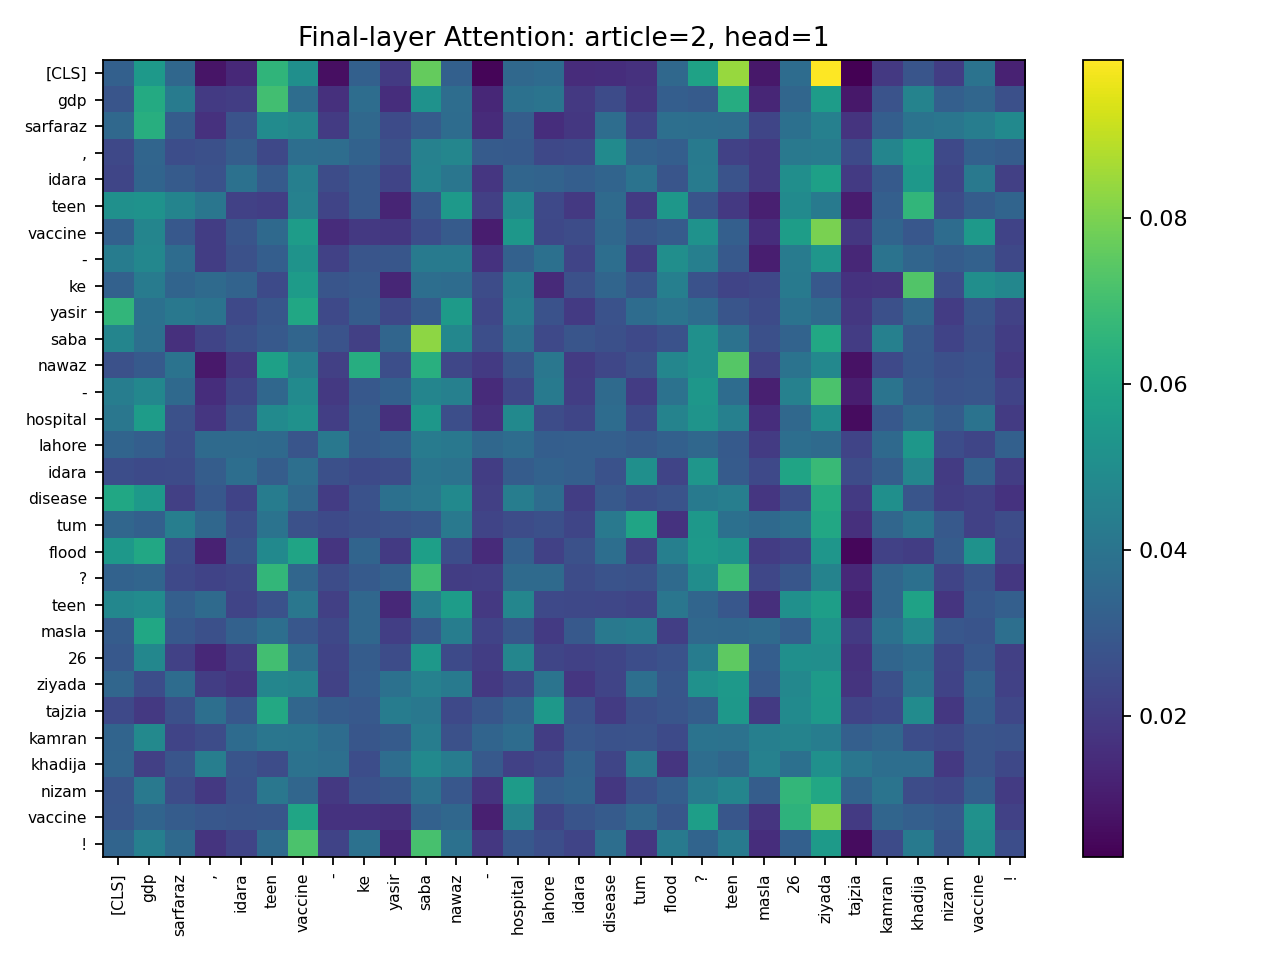


part3_attention_article3_head0.png


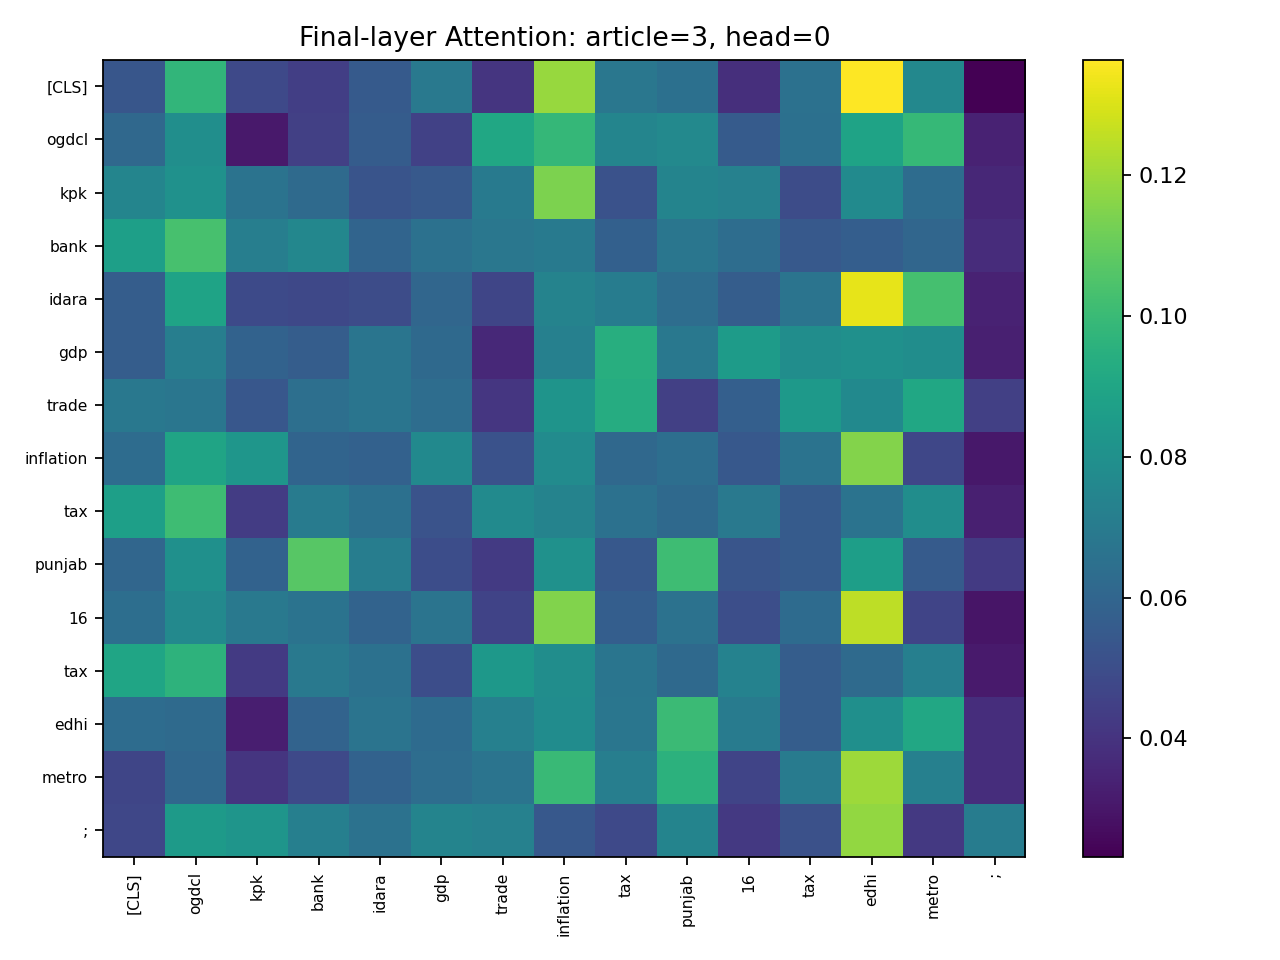


part3_attention_article3_head1.png


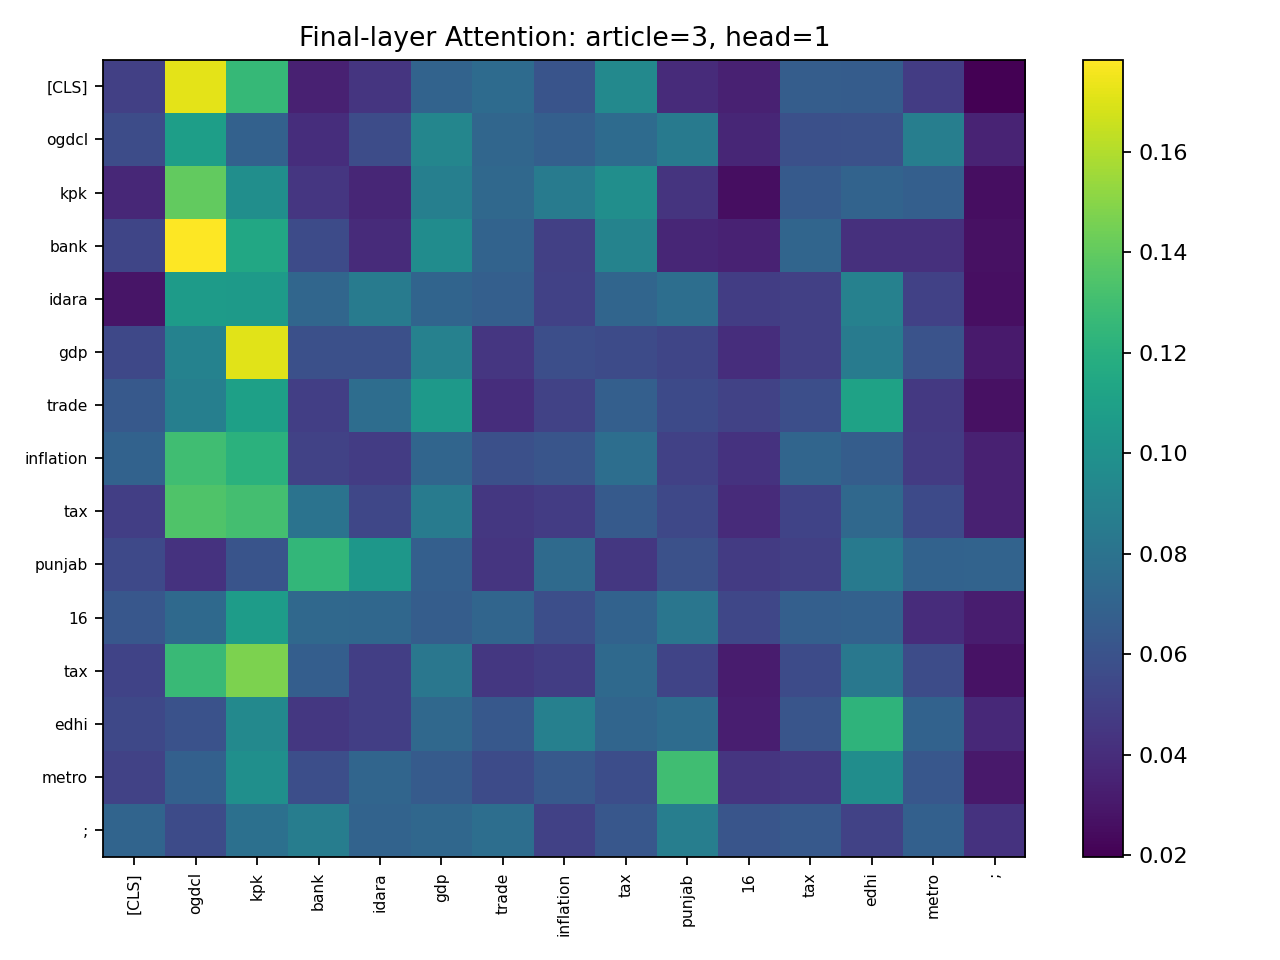

In [42]:
print("Attention heatmaps (2 heads x 3 correctly classified articles)")
for name in [
    "part3_attention_article1_head0.png",
    "part3_attention_article1_head1.png",
    "part3_attention_article2_head0.png",
    "part3_attention_article2_head1.png",
    "part3_attention_article3_head0.png",
    "part3_attention_article3_head1.png",
]:
    print()
    print(f"{name}")
    display(Image(filename=str(REPORTS / name)))

In [55]:
print("BiLSTM vs Transformer written comparison (10-15 sentences)")
print("=" * 72)
print(comparison_text)


BiLSTM vs Transformer written comparison (10-15 sentences)
The Transformer and BiLSTM were evaluated on the same 5-class split.
The Transformer reached test accuracy 0.9905, while the BiLSTM reached 0.9714.
The absolute accuracy difference is 0.0190 in favour of Transformer.
Transformer validation accuracy peaked at epoch 4.
BiLSTM validation accuracy peaked at epoch 3.
The model with fewer epochs to peak validation accuracy appears to converge faster; in this run that was BiLSTM.
Average Transformer training time per epoch was 7.38 seconds.
Average BiLSTM training time per epoch was 3.50 seconds.
Per-epoch runtime differs because multi-head attention performs dense token-token interactions, while recurrent models process steps sequentially and can be cheaper for short sequences.
Attention heatmaps in the final encoder layer highlight which tokens influence the [CLS] representation, and they can show focused patterns around topic-indicative words.
When the dataset is very small (around

## Conclusion

All required assignment outputs are included in this notebook as executed cell outputs.
The GitHub URL is included at the top of the notebook.
